# Basic Random Forest Classifier

## a. Lab Requirements

The third lab assignment is to use scikit-learn to implement a random forest classifier for the rice dataset, which is available at the following link:

https://archive.ics.uci.edu/ml/datasets/Rice+%28Cammeo+and+Osmancik%29

You must demonstrate to a tutor that your code works and prints out the following values:

1. Confusion matrix

2. Accuracy

3. Precision

4. Sensitivity

5. F1 score

## b. Imports

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score,confusion_matrix, classification_report

## c. Load Data

In [ ]:
from ucimlrepo import fetch_ucirepo 

# Load Dataset
rice_dataset = fetch_ucirepo(id=545)

# Features and target
X = rice_dataset.data.features
y = rice_dataset.data.targets

# Combine Features and Target
df = pd.concat([X, y], axis=1)

# Save Locally 
output_file = "rice_cammeo_osmancik.csv"
df.to_csv(output_file, index=False)

## d. Data Cleaning

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   str    
dtypes: float64(5), int64(2), str(1)
memory usage: 238.3 KB


Key Takeaways:

* We have no missing values.
* Our class column is a string, needs encoding.

In [21]:
df["Class"].unique()

<StringArray>
['Cammeo', 'Osmancik']
Length: 2, dtype: str

* We have two classes for our target column, `Cammeo` and `Osmancik`

In [22]:
# check for duplicates
total_duplicates = df.duplicated().sum()
print(total_duplicates)

0


* We have no duplicates in our dataset.

In [23]:
#Checking the summary stats
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144752,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


* No need for feature scaling because we'll use trees

In [24]:
#check class distribution in the dataset
df['Class'].value_counts(normalize=True) * 100

Class
Osmancik    57.217848
Cammeo      42.782152
Name: proportion, dtype: float64

* It's okay but we'll stratify during the split to keep it safe.

## e. Split the Raw Data

In [25]:
#split features and target columns
cols = ["Area",	"Perimeter", "Major_Axis_Length", "Minor_Axis_Length", "Eccentricity", "Convex_Area", "Extent"]
X = df[cols]
y = df["Class"]

#split to train & validation  and test sets (80/20)   we are spliting the data to training&validation and test data
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

#split the training and validation sets (75/25) training&validation then split to training and validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, shuffle=True, random_state=42)

## f. Data Preprocessing

### Encoding ncoding `Class` column

0 = Cammeo

1 = Osmancik

In [26]:
encoder = LabelEncoder()

# Fit on training labels, transform all three
y_train_encoded = encoder.fit_transform(y_train) 
y_val_encoded = encoder.transform(y_val.values)
y_test_encoded = encoder.transform(y_test.values)

## g. Modeling

### Building the Randomn Forest Classifier

In [ ]:
rfc = RandomForestClassifier(n_estimators=1000, criterion='gini', max_depth=10, max_samples=0.2, random_state=42)
rfc.fit(X_train, y_train_encoded)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

## h. Model Validation

In [28]:
#Model Validation
val_preds = rfc.predict(X=X_val)


In [29]:
val_matrix = confusion_matrix(y_true=y_val_encoded, y_pred=val_preds)
print(f"Confuion Matrx of the Validation dataset: \n {val_matrix}")

print("====================================================================")

val_report = classification_report(y_true=y_val_encoded, y_pred=val_preds)
print(f"Classification Report of the Validation dataset: \n {val_report}")

Confuion Matrx of the Validation dataset: 
 [[303  23]
 [ 23 413]]
Classification Report of the Validation dataset: 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93       326
           1       0.95      0.95      0.95       436

    accuracy                           0.94       762
   macro avg       0.94      0.94      0.94       762
weighted avg       0.94      0.94      0.94       762



In [30]:
print("Classes:", encoder.classes_)

Classes: ['Cammeo' 'Osmancik']


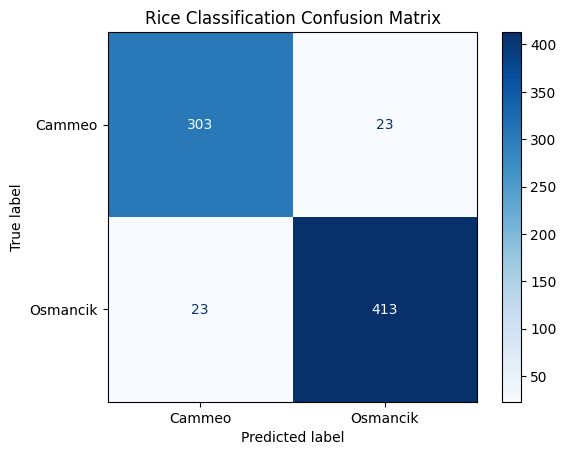

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true =y_val_encoded, y_pred =val_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cammeo", "Osmancik"]
)

disp.plot(cmap="Blues")
plt.title("Rice Classification Confusion Matrix")
plt.show()

## i. Model Testing

In [32]:
#Make preds on test set
preds = rfc.predict(X_test)

In [33]:
Test_matrix = confusion_matrix(y_true=y_test_encoded, y_pred=preds)
print(f"Confuion Matrx of the Validation dataset: \n {Test_matrix}")

print("====================================================================")

test_report = classification_report(y_true=y_test_encoded, y_pred=preds)
print(f"Classification Report of the Validation dataset: \n {test_report}")

Confuion Matrx of the Validation dataset: 
 [[287  39]
 [ 25 411]]
Classification Report of the Validation dataset: 
               precision    recall  f1-score   support

           0       0.92      0.88      0.90       326
           1       0.91      0.94      0.93       436

    accuracy                           0.92       762
   macro avg       0.92      0.91      0.91       762
weighted avg       0.92      0.92      0.92       762



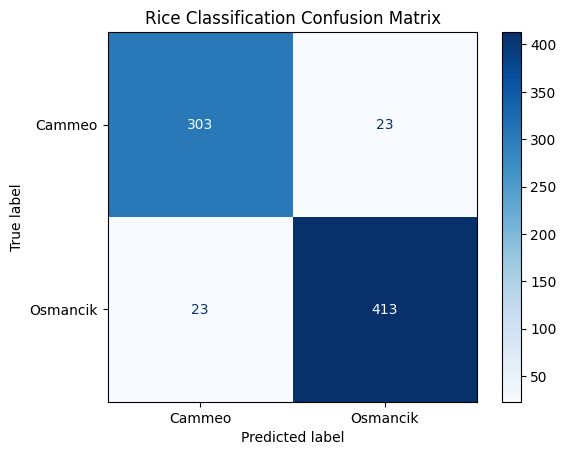

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true =y_val_encoded, y_pred =val_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cammeo", "Osmancik"]
)

disp.plot(cmap="Blues")
plt.title("Rice Classification Confusion Matrix")
plt.show()